In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, average_precision_score, precision_recall_curve, auc
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except ImportError:
    smote_available = False
    print("SMOTE not available – will use class weights instead.")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

SMOTE not available – will use class weights instead.


In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"Train shape: {X_train.shape}, Train fraud ratio: {y_train.mean():.5f}")
print(f"Test shape: {X_test.shape}, Test fraud ratio: {y_test.mean():.5f}")

Train shape: (103316, 196), Train fraud ratio: 0.09499
Test shape: (25830, 196), Test fraud ratio: 0.09501


In [3]:
if smote_available:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"SMOTE applied. New train fraud ratio: {y_train_res.mean():.2f}")
    use_smote = True
else:
    # Fallback: keep original data, but models will use class_weight/scale_pos_weight
    X_train_res, y_train_res = X_train, y_train
    use_smote = False
    print("Using original imbalanced training set – will rely on class weights.")
    

Using original imbalanced training set – will rely on class weights.


In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, use_class_weight=False):
    if use_class_weight and hasattr(model, 'class_weight'):
        model.set_params(class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n=== {model_name} ===")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-PR: {auc_pr:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return y_proba, model

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_proba, lr_model = evaluate_model(lr, X_train_res, y_train_res, X_test, y_test, 
                                    "Logistic Regression", use_class_weight=(not use_smote))


=== Logistic Regression ===
F1-Score: 0.6834
AUC-PR: 0.6308
Confusion Matrix:
[[23181   195]
 [ 1079  1375]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     23376
           1       0.88      0.56      0.68      2454

    accuracy                           0.95     25830
   macro avg       0.92      0.78      0.83     25830
weighted avg       0.95      0.95      0.95     25830



In [7]:
if use_smote:
    xgb = XGBClassifier(random_state=42, eval_metric='logloss')
else:
    ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])
    xgb = XGBClassifier(random_state=42, scale_pos_weight=ratio, eval_metric='logloss')

xgb_proba, xgb_model = evaluate_model(xgb, X_train_res, y_train_res, X_test, y_test, "XGBoost")


=== XGBoost ===
F1-Score: 0.6351
AUC-PR: 0.7189
Confusion Matrix:
[[22202  1174]
 [  766  1688]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     23376
           1       0.59      0.69      0.64      2454

    accuracy                           0.92     25830
   macro avg       0.78      0.82      0.80     25830
weighted avg       0.93      0.92      0.93     25830



In [8]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])  # from original training set

f1_scores = []
auc_pr_scores = []

for train_idx, val_idx in cv.split(X_train_res, y_train_res):
    X_tr, X_val = X_train_res.iloc[train_idx], X_train_res.iloc[val_idx]
    y_tr, y_val = y_train_res[train_idx], y_train_res[val_idx]
    
    model_cv = XGBClassifier(random_state=42, scale_pos_weight=ratio, eval_metric='logloss')
    model_cv.fit(X_tr, y_tr)
    
    y_pred_cv = model_cv.predict(X_val)
    y_proba_cv = model_cv.predict_proba(X_val)[:, 1]
    
    f1_scores.append(f1_score(y_val, y_pred_cv))
    auc_pr_scores.append(average_precision_score(y_val, y_proba_cv))

print("\n=== 5‑Fold Stratified CV on Training Set (XGBoost with class weights) ===")
print(f"F1 – mean: {np.mean(f1_scores):.4f}, std: {np.std(f1_scores):.4f}")
print(f"AUC-PR – mean: {np.mean(auc_pr_scores):.4f}, std: {np.std(auc_pr_scores):.4f}")


=== 5‑Fold Stratified CV on Training Set (XGBoost with class weights) ===
F1 – mean: 0.6232, std: 0.0039
AUC-PR – mean: 0.7048, std: 0.0036


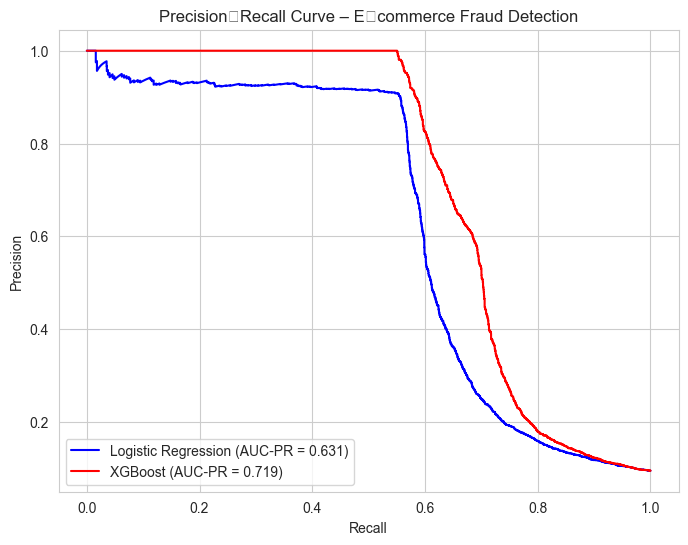

In [9]:
def plot_pr_curve(y_test, y_proba, model_name, color):
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{model_name} (AUC-PR = {pr_auc:.3f})', color=color)

plt.figure(figsize=(8,6))
plot_pr_curve(y_test, lr_proba, 'Logistic Regression', 'blue')
plot_pr_curve(y_test, xgb_proba, 'XGBoost', 'red')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve – E‑commerce Fraud Detection')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'F1-Score': [f1_score(y_test, lr_model.predict(X_test)), 
                 f1_score(y_test, xgb_model.predict(X_test))],
    'AUC-PR': [average_precision_score(y_test, lr_proba), 
               average_precision_score(y_test, xgb_proba)]
})
print("\n=== Model Comparison ===")
print(results)


=== Model Comparison ===
                 Model  F1-Score    AUC-PR
0  Logistic Regression  0.683400  0.630813
1              XGBoost  0.635064  0.718861


In [11]:
import joblib
joblib.dump(xgb_model, '../models/xgb_fraud_model.pkl')
print("XGBoost model saved to '../models/xgb_fraud_model.pkl'")

XGBoost model saved to '../models/xgb_fraud_model.pkl'
